<a href="https://colab.research.google.com/github/apHub27/sveltetech-ai-internship/blob/main/ANN_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training the ANN model
ANN training Finished :0.293595
True Label: Ankle boot 🥾
🎉 Model's Predicted Guess: Ankle boot 🥾


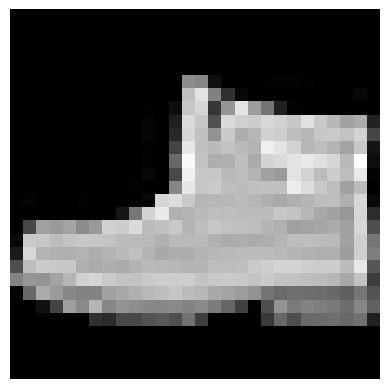

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
# data loading
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# ann architecture
class FashionANN(nn.Module):
    def __init__(self):
        super(FashionANN, self).__init__()
        self.fc1 = nn.Linear(784,128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):
      # flattening the img
      x = x.view(-1,784)
      x = self.fc1(x)
      x = self.relu(x)
      x = self.fc2(x)
      return x

model = FashionANN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#training loop
print("Training the ANN model")
for epoch in range(1):
  for batch_images, batch_labels in train_loader:
    optimizer.zero_grad()
    outputs = model(batch_images)
    loss = criterion(outputs, batch_labels)
    loss.backward()
    optimizer.step()
print(f"ANN training Finished :{loss.item():4f}")

model.eval()
images,labels = next(iter(train_loader))

single_img = images[0]
true_label_index = labels[0].item()

with torch.no_grad():
  output = model(single_img.unsqueeze(0))

predicted_label_index = torch.argmax(output).item()

clothing_categories = {
     0: "T-shirt 👕", 1: "Trouser 👖", 2: "Pullover 🧥", 3: "Dress 👗", 4: "Coat 🧥",
    5: "Sandal 👡", 6: "Shirt 👔", 7: "Sneaker 👟", 8: "Bag 👜", 9: "Ankle boot 🥾"

}
print(f"True Label: {clothing_categories[true_label_index]}")
print(f"🎉 Model's Predicted Guess: {clothing_categories[predicted_label_index]}")

plt.imshow(single_img.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

🚀 Training the CNN Model...
🎉 CNN Training Finished! Final Batch Loss: 0.1665
True Label: Shirt 👔
🎉 Model's Predicted Guess: Shirt 👔


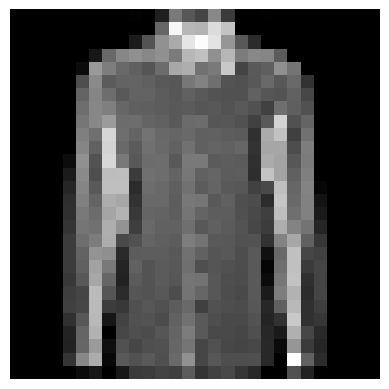

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# --- 1. DATA LOADING ---
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# --- 2. CNN ARCHITECTURE ---
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(16 * 14 * 14, 10)

    def forward(self, x):
        # Image square shape me hi rehti hai aur filter ispe slide hota hai
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        # Sirf end me classification ke liye linear vector banaya
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# --- 3. SETUP ---
model = FashionCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 4. TRAINING LOOP ---
print("🚀 Training the CNN Model...")
for epoch in range(3):
    for batch_images, batch_labels in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_images)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

print(f"🎉 CNN Training Finished! Final Batch Loss: {loss.item():.4f}")

model.eval()
images, labels = next(iter(train_loader))

single_img = images[0]
true_label_index = labels[0].item()

with torch.no_grad():
    output_scores = model(single_img.unsqueeze(0))
    predicted_label_index = torch.argmax(output_scores).item()

clothing_categories = {
 0: "T-shirt 👕", 1: "Trouser 👖", 2: "Pullover 🧥", 3: "Dress 👗", 4: "Coat 🧥",
    5: "Sandal 👡", 6: "Shirt 👔", 7: "Sneaker 👟", 8: "Bag 👜", 9: "Ankle boot 🥾"
}

print(f"True Label: {clothing_categories[true_label_index]}")
print(f"🎉 Model's Predicted Guess: {clothing_categories[predicted_label_index]}")


plt.imshow(single_img.squeeze(), cmap='gray')
plt.axis('off')
plt.show()